In [ ]:
from analysis.sensitivity import scan_sensitivity
from analysis.rate_models import get_rate_ben, get_rate_14, get_rate_12
#, get_rate_13
from analysis.dm_params import DMParams
import numpy as np
import analysis.plotter as plotter
import matplotlib.pyplot as plt

In [2]:
params = DMParams(m_D_GeV = 5,
                 sigma_pb = 0.1,
                 rho_GeV_cm3 = 0.3,
                 v0_kms = 230,
                 vE_kms = 250,
                 vesc_kms = 600,
                 exposure_kgdays = 11,
                 confidence_level = 0.9,
                 mass_number_A = 28,
                 c1 = 0.751, c2 = 0.561,
                 E_min_KeV= 0.63
                 )

In [3]:
E_Rs_KeV = np.linspace(0.0001, 10, 1000)
dRs0 = [get_rate_ben(E, params) for E in E_Rs_KeV]
dRs1 = [get_rate_12(E, params) for E in E_Rs_KeV]

Text(0.5, 1.0, 'Differential Rate (for v_esc. = inf)')

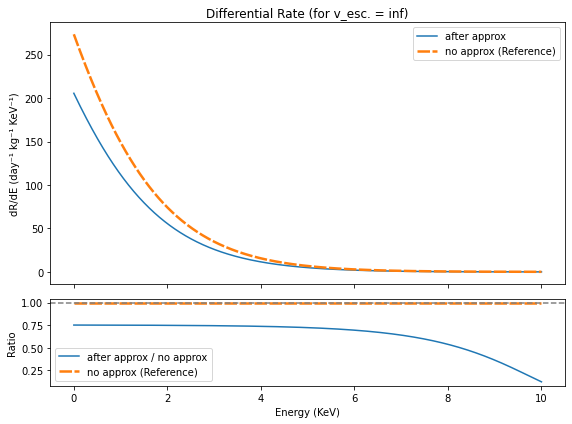

In [4]:
fig, axes = plotter.plot_differential_rate(E_Rs_KeV, [dRs0, dRs1], ref_index = 1, 
                               labels=["after approx","no approx"], panel_type= "ratio")
axes[0].set_title("Differential Rate (for v_esc. = inf)")
# axes[1].set_ylim(0, 5)

In [5]:
# scan_sensitivity(params, get_rate_ben, npoints=30)

In [6]:
# mass_ben, xs_ben = scan_sensitivity(params, get_rate_ben, npoints=300)

data_ben = np.load("data/sensitivity_new.npz") 
# data_ben = np.load("/Users/iumicuszhu/Documents/DAMIC-M/WIMPyCCD/data/contour13.npz") 

mass_ben, xs_ben = data_ben["mass"],data_ben["xs"]

In [7]:
rad_file = '/Users/iumicuszhu/Downloads/Default Dataset.csv'
data_rad = np.loadtxt(rad_file, delimiter=",") 
mass_rad, xs_rad = data_rad[:,0], data_rad[:,1]*1e36
# import damic paper data:

data = np.loadtxt("digitized/DAMIC results/nominal.csv", delimiter=",") 
upper = np.loadtxt("digitized/DAMIC results/upper.csv", delimiter=",") 
lower = np.loadtxt("digitized/DAMIC results/lower.csv", delimiter=",") 

mass2, xs2 = upper[:,0], upper[:,1]*1e36
mass3, xs3 = lower[:,0], lower[:,1]*1e36
mass4, xs4 = data[:,0], data[:,1]*1e36

<Figure size 1008x1440 with 0 Axes>

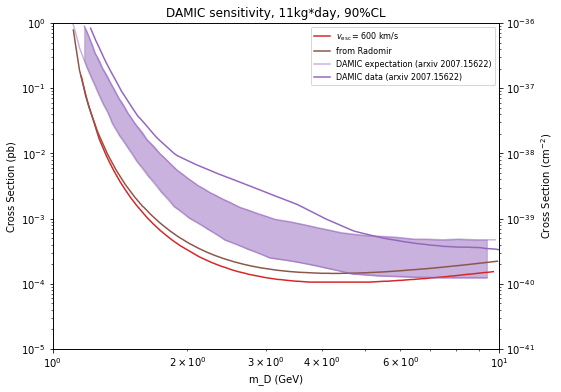

In [8]:
plt.figure(figsize=(14, 20))
fig, ax1 = plt.subplots(figsize=(8, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # default color cycle
ax1.plot(mass_ben, xs_ben, label=r'$v_{\mathrm{esc}}=600$ km/s', color=colors[3])
ax1.plot(mass_rad, xs_rad, label='from Radomir', color=colors[5])


# digitalized from paper
ax1.plot(mass2, xs2, color=colors[4], alpha=0.5)
ax1.plot(mass3, xs3, label='DAMIC expectation (arxiv 2007.15622)', color=colors[4], alpha=0.5)
ax1.plot(mass4, xs4, label='DAMIC data (arxiv 2007.15622)', color=colors[4], alpha=1)
common_mass = np.linspace(max(min(mass2), min(mass3)), min(max(mass2), max(mass3)), 500)
xs2_interp = np.interp(common_mass, mass2, xs2)
xs3_interp = np.interp(common_mass, mass3, xs3)
ax1.fill_between(common_mass, xs2_interp, xs3_interp, color=colors[4], alpha=0.5)


ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('DAMIC sensitivity, 11kg*day, 90%CL')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('Cross Section (pb)')
ax1.set_xlim(1,10)
ax1.set_ylim(1e-5,1e0)

ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")

# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title='v0 = 230km/s, Emin = 0.63 KeV, CL = 90%, Si A=28, 11kg*day, 95%CL')
ax1.legend(fontsize = 8)

plt.show()

fig.savefig("sensitivity_plot.png", dpi=600) 

In [9]:
E_Rs_KeV = np.linspace(0.0001, 2, 1000)
dRs0 = [get_rate_ben(E, params) for E in E_Rs_KeV]
dRs1 = [get_rate_14(E, params) for E in E_Rs_KeV]

Text(0.5, 1.0, 'Differential Rate (for v_esc. = inf)')

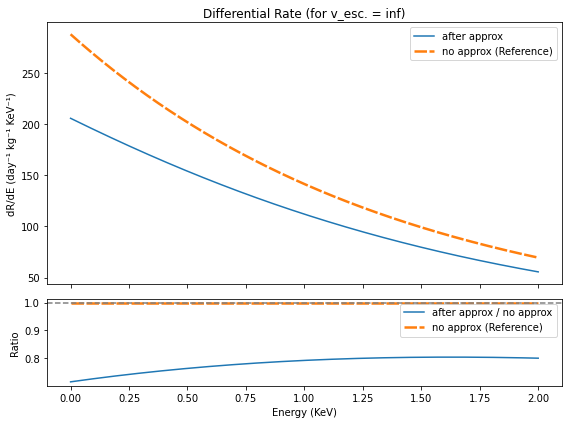

In [10]:
fig, axes = plotter.plot_differential_rate(E_Rs_KeV, [dRs0, dRs1], ref_index = 1, 
                               labels=["after approx","no approx"], panel_type= "ratio")
axes[0].set_title("Differential Rate (for v_esc. = inf)")
# axes[1].set_ylim(0, 5)

In [11]:
get_rate_ben(0.1, params)

194.49284303784145

In [12]:
get_rate_14(0.1, params)

267.86386871844303